ANN Accuracy: 0.8268156424581006


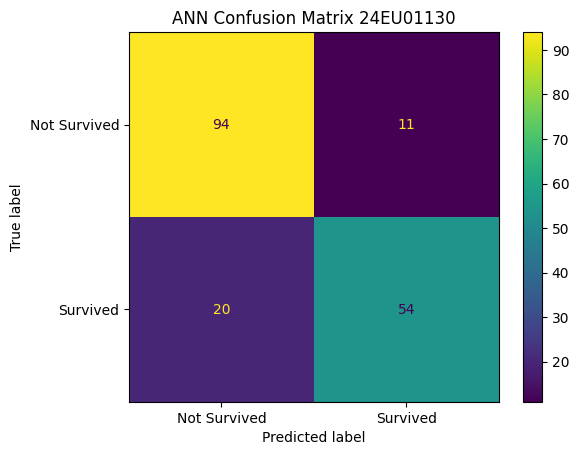

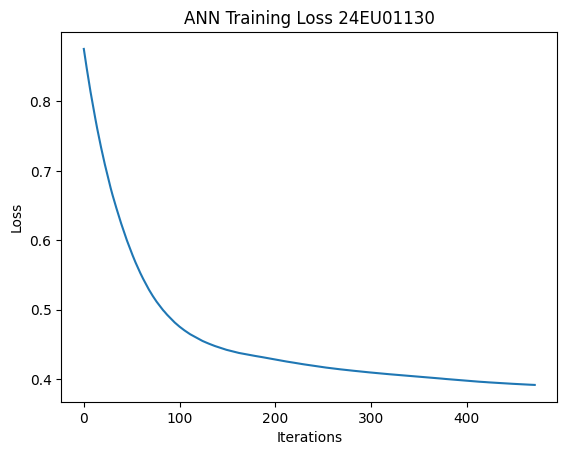

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ann = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

ann.fit(X_train, y_train)

y_pred = ann.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("ANN Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Survived", "Survived"]
)

disp.plot()
plt.title("ANN Confusion Matrix 24EU01130")
plt.show()

plt.plot(ann.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("ANN Training Loss 24EU01130")
plt.show()